# 01 — Dataset Exploration

## Wi-Fi Indoor Localization using UJIIndoorLoc

This notebook explores the UJIIndoorLoc Wi-Fi fingerprint dataset before model training.

We will:

- Load the training and validation datasets
- Inspect the dataset dimensions and columns
- Identify the 520 WAP/RSSI features
- Examine building and floor distributions
- Understand the special `100` value used for an unobserved WAP
- Analyze how many Wi-Fi access points are observed per sample
- Create visualizations that will be useful for the final report and presentation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## 1. Locate the Dataset

The UJIIndoorLoc dataset is stored in the `data/raw/` directory.

It contains:

- `trainingData.csv`
- `validationData.csv`

The notebook will locate these files relative to the project folder.

In [3]:
from pathlib import Path

project_root = Path.cwd()

# If the notebook is running from the notebooks folder,
# move one level up to the project root.
if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

data_dir = project_root / "data" / "raw"

train_path = data_dir / "trainingData.csv"
valid_path = data_dir / "validationData.csv"

print("Project root:", project_root)
print("Data directory:", data_dir)
print("Training file exists:", train_path.exists())
print("Validation file exists:", valid_path.exists())

Project root: c:\Users\anvii\Downloads\wifi_indoor_localization_project
Data directory: c:\Users\anvii\Downloads\wifi_indoor_localization_project\data\raw
Training file exists: True
Validation file exists: True


## 2. Load the Training and Validation Data

We now load both CSV files into pandas DataFrames.

The training dataset will be used for the machine-learning experiments, while the validation dataset is kept separate for later evaluation.

In [4]:
train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)

print("Training shape:", train_df.shape)
print("Validation shape:", valid_df.shape)

Training shape: (19937, 529)
Validation shape: (1111, 529)


## 3. Inspect the Dataset

Before building models, we inspect a few rows to understand the structure of the data.

In [5]:
train_df.head()

,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


## 4. Identify Wi-Fi RSSI Features

The Wi-Fi fingerprint is represented by WAP (Wireless Access Point) RSSI measurements.

The WAP columns are named from `WAP001` to `WAP520`.

In [6]:
wap_columns = [col for col in train_df.columns if col.startswith("WAP")]

print("Number of WAP columns:", len(wap_columns))
print("First 10 WAP columns:", wap_columns[:10])
print("Last 10 WAP columns:", wap_columns[-10:])

Number of WAP columns: 520
First 10 WAP columns: ['WAP001', 'WAP002', 'WAP003', 'WAP004', 'WAP005', 'WAP006', 'WAP007', 'WAP008', 'WAP009', 'WAP010']
Last 10 WAP columns: ['WAP511', 'WAP512', 'WAP513', 'WAP514', 'WAP515', 'WAP516', 'WAP517', 'WAP518', 'WAP519', 'WAP520']


## 5. Identify Target and Metadata Columns

Apart from the WAP features, the dataset contains information describing the location of each fingerprint.

The main location fields we will use later include:

- `BUILDINGID`
- `FLOOR`
- `LATITUDE`
- `LONGITUDE`

In [7]:
non_wap_columns = [col for col in train_df.columns if col not in wap_columns]

print("Number of non-WAP columns:", len(non_wap_columns))
print("\nNon-WAP columns:")
print(non_wap_columns)

Number of non-WAP columns: 9

Non-WAP columns:
['LONGITUDE', 'LATITUDE', 'FLOOR', 'BUILDINGID', 'SPACEID', 'RELATIVEPOSITION', 'USERID', 'PHONEID', 'TIMESTAMP']


## 6. Building and Floor Distribution

We examine how many training samples belong to each building-floor combination.

This helps us understand the distribution of the supervised learning target.

In [8]:
floor_counts = (
    train_df
    .groupby(["BUILDINGID", "FLOOR"])
    .size()
    .reset_index(name="Samples")
)

display(floor_counts)

,BUILDINGID,FLOOR,Samples
0,0,0,1059
1,0,1,1356
2,0,2,1443
3,0,3,1391
4,1,0,1368
5,1,1,1484
6,1,2,1396
7,1,3,948
8,2,0,1942
9,2,1,2162


## 7. Visualize the Building-Floor Distribution

In [13]:
floor_counts_plot = floor_counts.copy()

floor_counts_plot["Building-Floor"] = (
    "B" + floor_counts_plot["BUILDINGID"].astype(str)
    + "-F" + floor_counts_plot["FLOOR"].astype(str)
)

display(floor_counts_plot)

,BUILDINGID,FLOOR,Samples,Building-Floor
0,0,0,1059,B0-F0
1,0,1,1356,B0-F1
2,0,2,1443,B0-F2
3,0,3,1391,B0-F3
4,1,0,1368,B1-F0
5,1,1,1484,B1-F1
6,1,2,1396,B1-F2
7,1,3,948,B1-F3
8,2,0,1942,B2-F0
9,2,1,2162,B2-F1


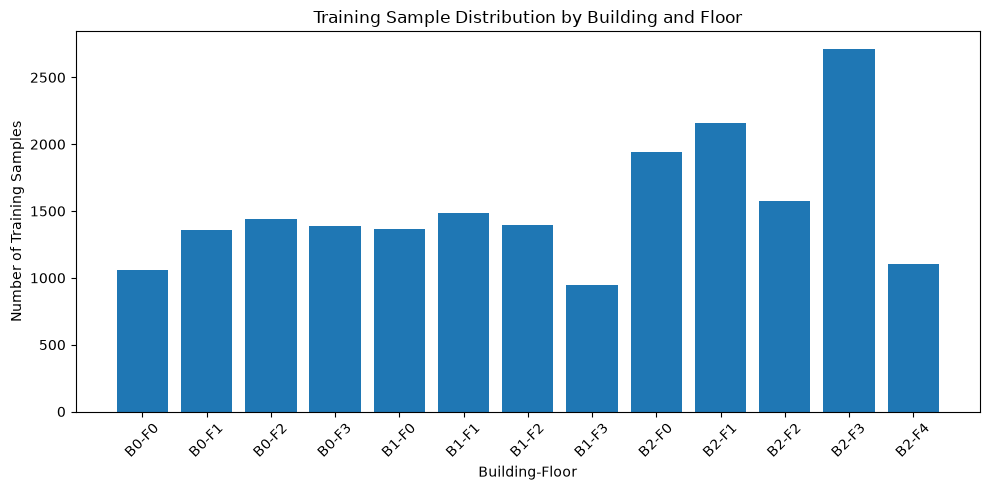

In [10]:
figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(10, 5))

plt.bar(
    floor_counts_plot["Building-Floor"],
    floor_counts_plot["Samples"]
)

plt.xlabel("Building-Floor")
plt.ylabel("Number of Training Samples")
plt.title("Training Sample Distribution by Building and Floor")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    figures_dir / "class_distribution.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 8. Investigate Missing Wi-Fi Measurements

In the raw dataset, a WAP value of 100 is used as the marker for an unobserved Wi-Fi access point.

We therefore need to understand how frequently this value occurs before preprocessing the data for machine learning.

In [11]:
X_wap = train_df[wap_columns]

print("Minimum WAP value:", X_wap.min().min())
print("Maximum WAP value:", X_wap.max().max())

print("Raw NaN count:", int(X_wap.isna().sum().sum()))

count_100 = int((X_wap == 100).sum().sum())

print("Count of 100 values:", count_100)

Minimum WAP value: -104
Maximum WAP value: 100
Raw NaN count: 0
Count of 100 values: 10008477


In [12]:
total_wap_entries = X_wap.size

missing_marker_percentage = (
    (X_wap == 100).sum().sum()
    / total_wap_entries
    * 100
)

print(f"Total WAP entries: {total_wap_entries:,}")
print(f"Entries marked as 100: {count_100:,}")
print(f"Percentage marked as 100: {missing_marker_percentage:.2f}%")

Total WAP entries: 10,367,240
Entries marked as 100: 10,008,477
Percentage marked as 100: 96.54%


## 9. Number of Observed WAPs per Sample

The raw dataset uses `100` as the marker for an unobserved Wi-Fi access point.

For each sample, we count the number of WAP measurements that are actually observed.

In [14]:
observed_wap_count = (X_wap != 100).sum(axis=1)

print("Observed WAP count statistics:")
print(observed_wap_count.describe())

Observed WAP count statistics:
count    19937.000000
mean        17.994834
std          7.333575
min          0.000000
25%         13.000000
50%         17.000000
75%         22.000000
max         51.000000
dtype: float64


## 10. Distribution of Observed WAPs

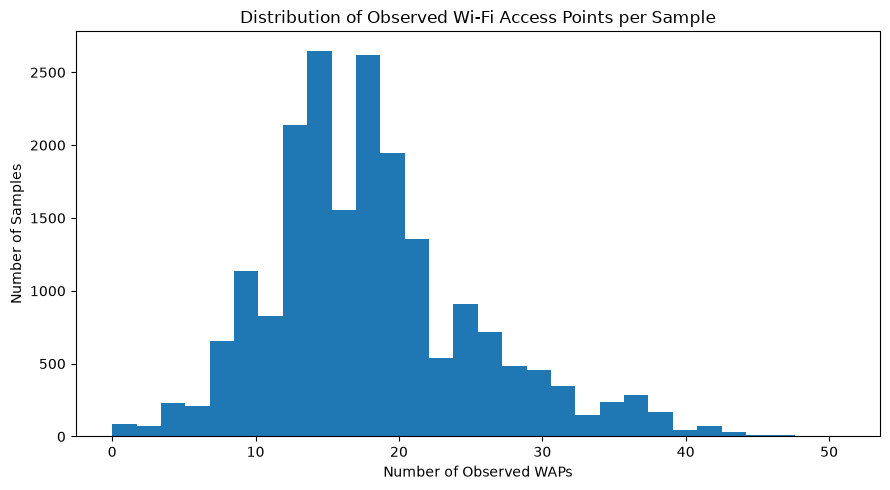

In [15]:
plt.figure(figsize=(9, 5))

plt.hist(observed_wap_count, bins=30)

plt.xlabel("Number of Observed WAPs")
plt.ylabel("Number of Samples")
plt.title("Distribution of Observed Wi-Fi Access Points per Sample")

plt.tight_layout()

plt.savefig(
    figures_dir / "observed_wap_count.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 11. Summary

The dataset contains Wi-Fi RSSI fingerprints represented by 520 WAP features.

The training and validation datasets contain location-related information including building, floor, latitude, and longitude.

The raw WAP measurements use `100` as the marker for an unobserved access point. The analysis shows that unobserved WAP measurements make up a large proportion of the raw feature matrix, making appropriate preprocessing important before model training.

The variation in the number of observed WAPs across samples also motivates the investigation of approaches that can handle sparse Wi-Fi fingerprints.